# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 1. Preprocessing and logreg visualization

In [2]:
def plot_decision_bondary(clf, X, ax, xlim, ylim):
    count = 500
    am_range = np.linspace(xlim[0], xlim[1], count)
    pm_range = np.linspace(ylim[0], ylim[1], count)
    xx, yy = np.meshgrid(am_range, pm_range)
    new_X = np.vstack((xx.flatten(), yy.flatten())).T
    if isinstance(clf, SVC):
        Z = clf.decision_function(new_X)
        level = 0
    else:
        Z = clf.predict_proba(new_X)[:, 1]
        level = 0.5
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[level])

In [3]:
def plot_features(clf, df, X, hue):
    fig, ax = plt.subplots()
    # sns.scatterplot(x='am', y='pm', hue=hue, data=df, hue_order=['working_day', 'weekend'], ax=ax)
    df.query(f"{hue} == 'working_day'").plot.scatter(x='am', y='pm', marker='o', color='b', ax=ax, label='working_day')
    df.query(f"{hue} == 'weekend'").plot.scatter(x='am', y='pm', marker='x', color='r', ax=ax, label='weekend')
    ax.legend(loc='upper left')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    plot_decision_bondary(clf=clf, X=X, ax=ax, xlim=xlim, ylim=ylim)
    plt.show()

In [4]:
df = pd.read_csv('../data/am_pm.csv')
X = df[['am', 'pm']]
y = df.target
logreg_clf = LogisticRegression(random_state=21, fit_intercept=False)
logreg_clf.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",21
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


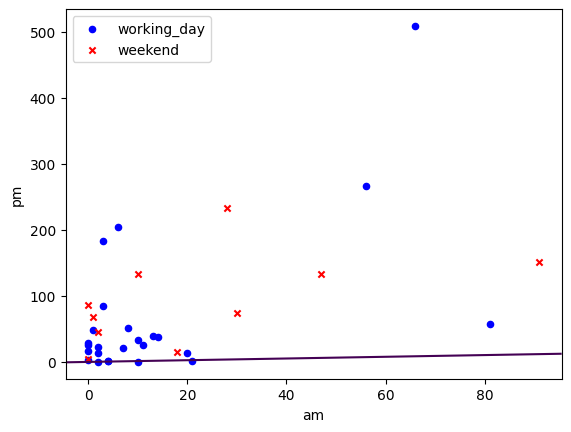

In [5]:
plot_features(clf=logreg_clf, df=df, X=X, hue='target')

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


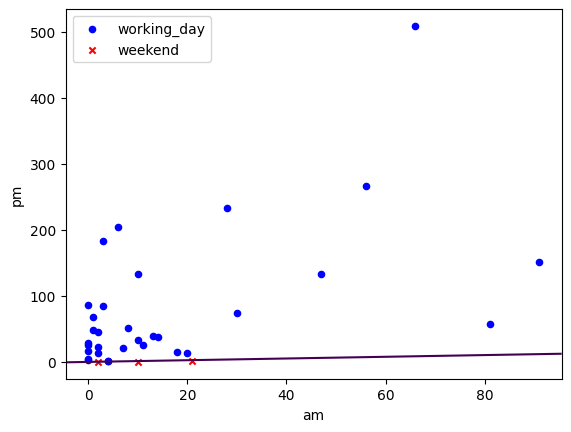

In [6]:
plot_features(clf=logreg_clf, df=df, X=X, hue='predict')

## 2. Standardizing and logreg

In [7]:
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns)
df_scaled = df.copy()
df_scaled[['am', 'pm']] = X_scaled
scaled_logreg_clf = LogisticRegression(random_state=21, fit_intercept=False)
scaled_logreg_clf.fit(X_scaled, y)
df_scaled.predict = scaled_logreg_clf.predict(X_scaled)

In [8]:
scaled_logreg_accuracy = scaled_logreg_clf.score(X_scaled, y)
scaled_logreg_accuracy

0.7428571428571429

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


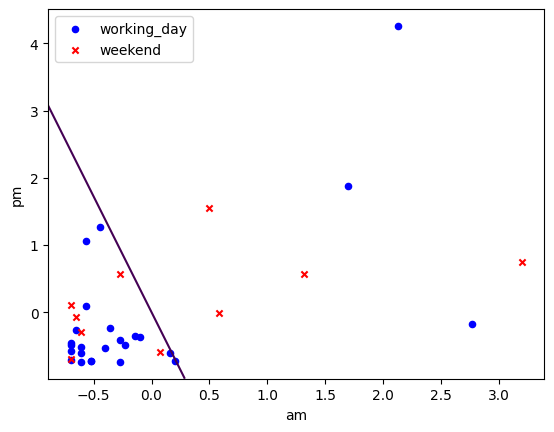

In [9]:
plot_features(clf=scaled_logreg_clf, df=df_scaled, X=X_scaled, hue='target')

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


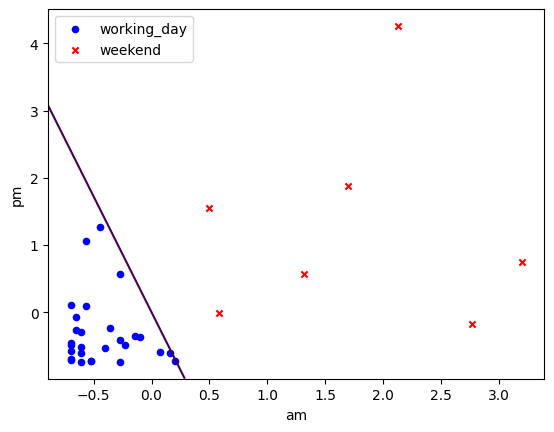

In [10]:
plot_features(clf=scaled_logreg_clf, df=df_scaled, X=X_scaled, hue='predict')

## 3. SVM

In [11]:
svc_clf = SVC(probability=True, random_state=21)
svc_clf.fit(X_scaled, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
svc_accuracy = svc_clf.score(X_scaled, y)
svc_accuracy

0.7428571428571429

In [13]:
svc_accuracy = 0
best_kernel = None
for kernel in ['linear', 'poly', 'rbf', 'sigmoid']:
    svc_clf_kernel = SVC(probability=True, random_state=21, kernel=kernel)
    svc_clf_kernel.fit(X_scaled, y)
    accuracy = svc_clf_kernel.score(X_scaled, y)
    print(f"kernel : '{kernel}', accuracy: {accuracy}")
    if accuracy > svc_accuracy:
        svc_accuracy = accuracy
        best_kernel = kernel
        svc_clf = svc_clf_kernel

kernel : 'linear', accuracy: 0.7142857142857143
kernel : 'poly', accuracy: 0.7428571428571429
kernel : 'rbf', accuracy: 0.7428571428571429
kernel : 'sigmoid', accuracy: 0.6857142857142857


In [14]:
svc_accuracy

0.7428571428571429

In [15]:
best_kernel

'poly'

In [16]:
df_scaled.predict = svc_clf.predict(X_scaled)

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


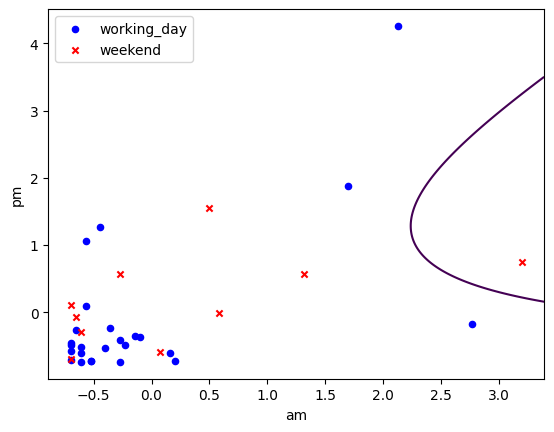

In [17]:
plot_features(clf=svc_clf, df=df_scaled, X=X_scaled, hue='target')

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


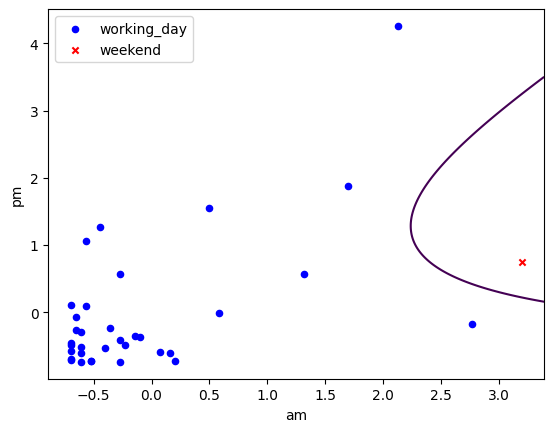

In [18]:
plot_features(clf=svc_clf, df=df_scaled, X=X_scaled, hue='predict')

## 4. Decision tree

In [19]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_scaled, y)
df_scaled.predict = tree_clf.predict(X_scaled)

In [20]:
tree_accuracy = tree_clf.score(X_scaled, y)
tree_accuracy

0.9428571428571428

In [21]:
tree_accuracy = 0
best_max_depth = None
for max_depth in range(1, 7):
    tree_clf_depth = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree_clf_depth.fit(X_scaled, y)
    accuracy = tree_clf_depth.score(X_scaled, y)
    print(f"max_depth : {max_depth}, accuracy: {accuracy}")

max_depth : 1, accuracy: 0.7714285714285715
max_depth : 2, accuracy: 0.8571428571428571
max_depth : 3, accuracy: 0.8857142857142857
max_depth : 4, accuracy: 0.9428571428571428
max_depth : 5, accuracy: 0.9714285714285714
max_depth : 6, accuracy: 1.0


/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


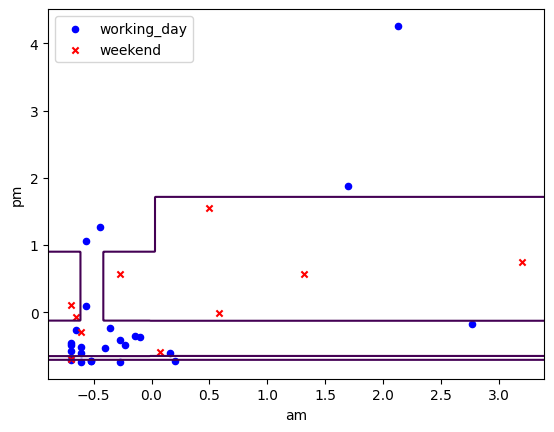

In [22]:
plot_features(clf=tree_clf, df=df_scaled, X=X_scaled, hue='target')

/Users/andrejpolozkov/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


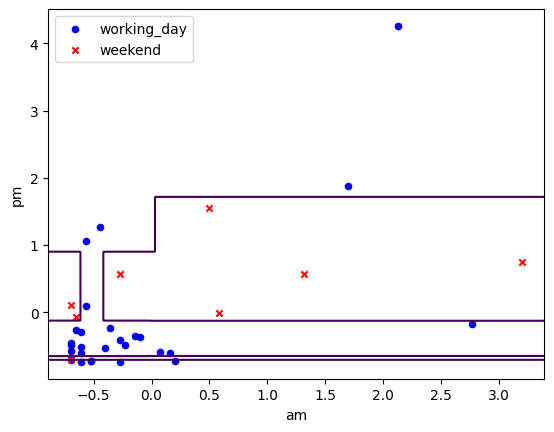

In [23]:
plot_features(clf=tree_clf, df=df_scaled, X=X_scaled, hue='predict')

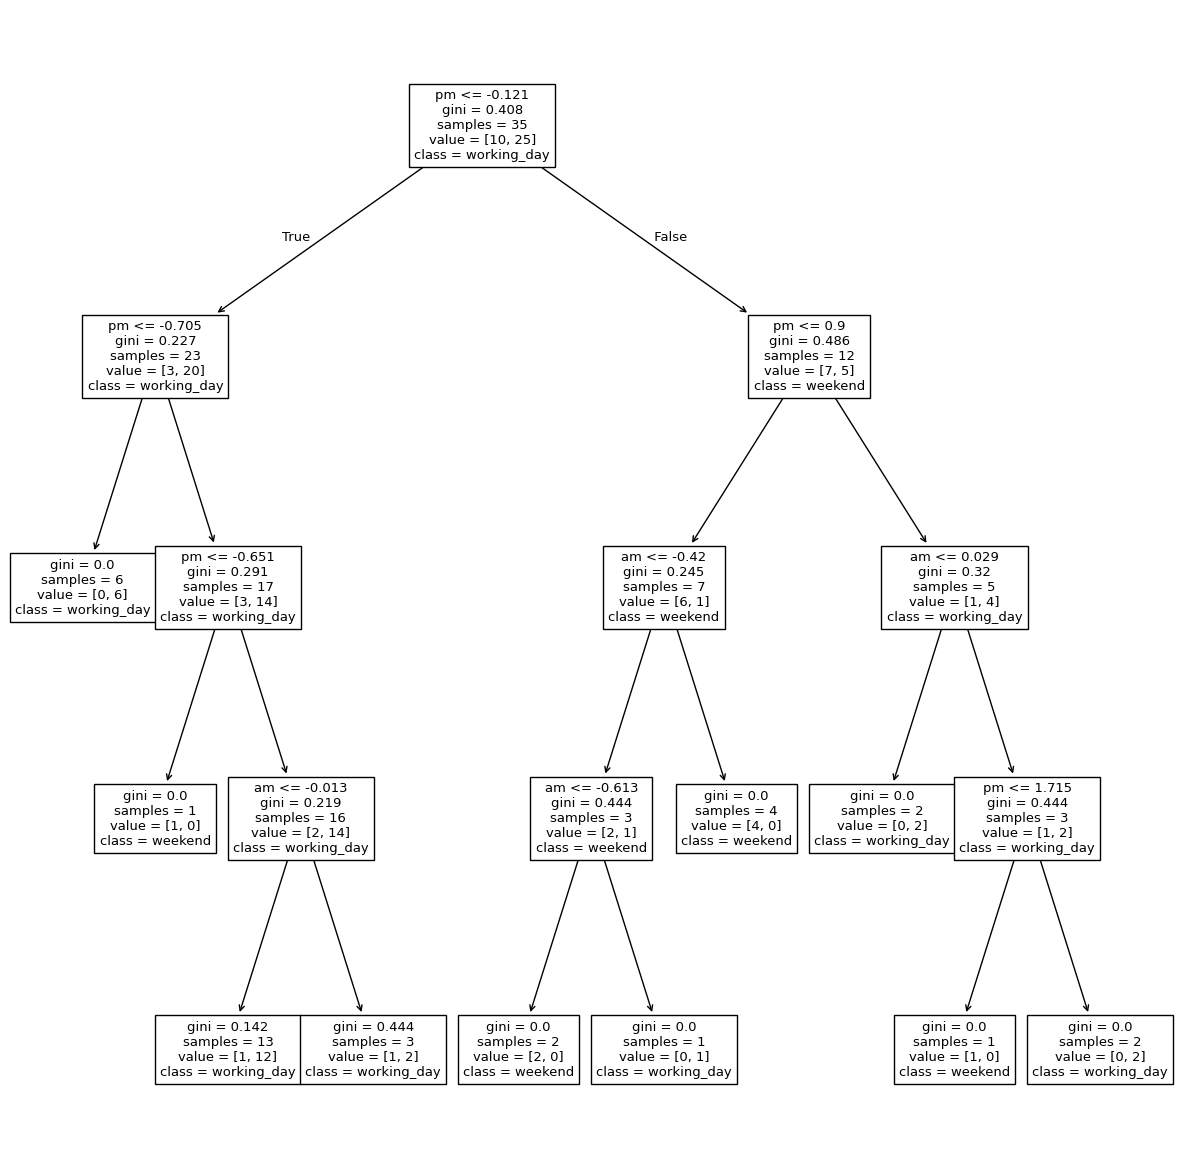

In [24]:
fig, ax = plt.subplots(figsize=(15, 15))
plot_tree(tree_clf, feature_names=X_scaled.columns, class_names=tree_clf.classes_, ax=ax)
plt.show()

*answer: 6. В чеклисте то ли перепутаны классы, то ли имеются в виду только листья с gini = 0. Тогда получится 4*